In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cargar los datasets
df = pd.read_parquet("../data/dataset_conversaciones/dataset_50k_anonymized.parquet")
hey_clientes = pd.read_csv("../data/dataset_transacciones/hey_clientes.csv")
hey_productos = pd.read_csv("../data/dataset_transacciones/hey_productos.csv")
hey_transacciones = pd.read_csv("../data/dataset_transacciones/hey_transacciones.csv")

In [4]:
print("Clientes:", hey_clientes.shape)
print("Productos:", hey_productos.shape)
print("Transacciones:", hey_transacciones.shape)
print("Conversaciones:", df.shape)

Clientes: (15025, 22)
Productos: (38909, 13)
Transacciones: (802384, 22)
Conversaciones: (49999, 6)


In [5]:
merged = pd.merge(df[["user_id"]].drop_duplicates(), hey_clientes[["user_id"]].drop_duplicates(), on="user_id", how="inner")
print(f"Number of unique users in conversations: {df['user_id'].nunique()}")
print(f"Number of unique users in hey_clientes: {hey_clientes['user_id'].nunique()}")
print(f"Number of users in both datasets: {merged['user_id'].nunique()}")

Number of unique users in conversations: 15025
Number of unique users in hey_clientes: 15025
Number of users in both datasets: 15025


Todos los usuarios (hey_clientes) han hecho al menos una interacción con Havi

In [6]:
for nombre, data  in [("clientes", hey_clientes), ("productos", hey_productos),
                   ("transacciones", hey_transacciones), ("conversaciones", df)]:
    print(f"\n=== {nombre.upper()} ===")
    info = pd.DataFrame({
        "tipo": data.dtypes,
        "nulos": data.isnull().sum(),
        "% nulos": (data.isnull().mean() * 100).round(2),
        "únicos": data.nunique()
    })
    display(info)


=== CLIENTES ===


,tipo,nulos,% nulos,únicos
user_id,str,0,0.00,15025
edad,int64,0,0.00,43
sexo,str,0,0.00,3
estado,str,432,2.88,17
ciudad,str,432,2.88,83
nivel_educativo,str,0,0.00,4
ocupacion,str,0,0.00,6
ingreso_mensual_mxn,int64,0,0.00,151
antiguedad_dias,int64,0,0.00,1816
es_hey_pro,bool,0,0.00,2



=== PRODUCTOS ===


,tipo,nulos,% nulos,únicos
producto_id,str,0,0.00,38909
user_id,str,0,0.00,15025
tipo_producto,str,0,0.00,11
fecha_apertura,str,0,0.00,1733
estatus,str,0,0.00,4
limite_credito,float64,24592,63.20,490
saldo_actual,float64,3750,9.64,34665
utilizacion_pct,float64,24592,63.20,6791
tasa_interes_anual,float64,20118,51.71,4782
plazo_meses,float64,34359,88.31,7



=== TRANSACCIONES ===


,tipo,nulos,% nulos,únicos
transaccion_id,str,0,0.00,802213
user_id,str,0,0.00,15025
producto_id,str,0,0.00,29972
fecha_hora,str,0,0.00,789602
tipo_operacion,str,0,0.00,12
canal,str,0,0.00,9
monto,float64,0,0.00,219519
comercio_nombre,str,370538,46.18,75
categoria_mcc,str,0,0.00,14
ciudad_transaccion,str,19267,2.40,93



=== CONVERSACIONES ===


,tipo,nulos,% nulos,únicos
input,object,0,0.0,41889
output,object,0,0.0,45307
date,object,0,0.0,3213
conv_id,object,0,0.0,24119
user_id,object,0,0.0,15025
channel_source,object,0,0.0,2


In [7]:
u_clientes = set(hey_clientes.user_id)
u_productos = set(hey_productos.user_id)
u_tx = set(hey_transacciones.user_id)
u_conv = set(df.user_id)

print(f"Usuarios en clientes:        {len(u_clientes):,}")
print(f"Usuarios con productos:      {len(u_productos):,}")
print(f"Usuarios con transacciones:  {len(u_tx):,}")
print(f"Usuarios con conversaciones: {len(u_conv):,}")
print(f"\nIntersección clientes ∩ tx ∩ conv: {len(u_clientes & u_tx & u_conv):,}")
print(f"Cobertura conversacional: {len(u_conv & u_clientes) / len(u_clientes):.1%}")

Usuarios en clientes:        15,025
Usuarios con productos:      15,025
Usuarios con transacciones:  15,025
Usuarios con conversaciones: 15,025

Intersección clientes ∩ tx ∩ conv: 15,025
Cobertura conversacional: 100.0%


## EDA Clientes

In [8]:
print(hey_clientes.info())

<class 'pandas.DataFrame'>
RangeIndex: 15025 entries, 0 to 15024
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  15025 non-null  str    
 1   edad                     15025 non-null  int64  
 2   sexo                     15025 non-null  str    
 3   estado                   14593 non-null  str    
 4   ciudad                   14593 non-null  str    
 5   nivel_educativo          15025 non-null  str    
 6   ocupacion                15025 non-null  str    
 7   ingreso_mensual_mxn      15025 non-null  int64  
 8   antiguedad_dias          15025 non-null  int64  
 9   es_hey_pro               15025 non-null  bool   
 10  nomina_domiciliada       15025 non-null  bool   
 11  canal_apertura           15025 non-null  str    
 12  score_buro               15025 non-null  int64  
 13  dias_desde_ultimo_login  15025 non-null  int64  
 14  preferencia_canal        15025 no

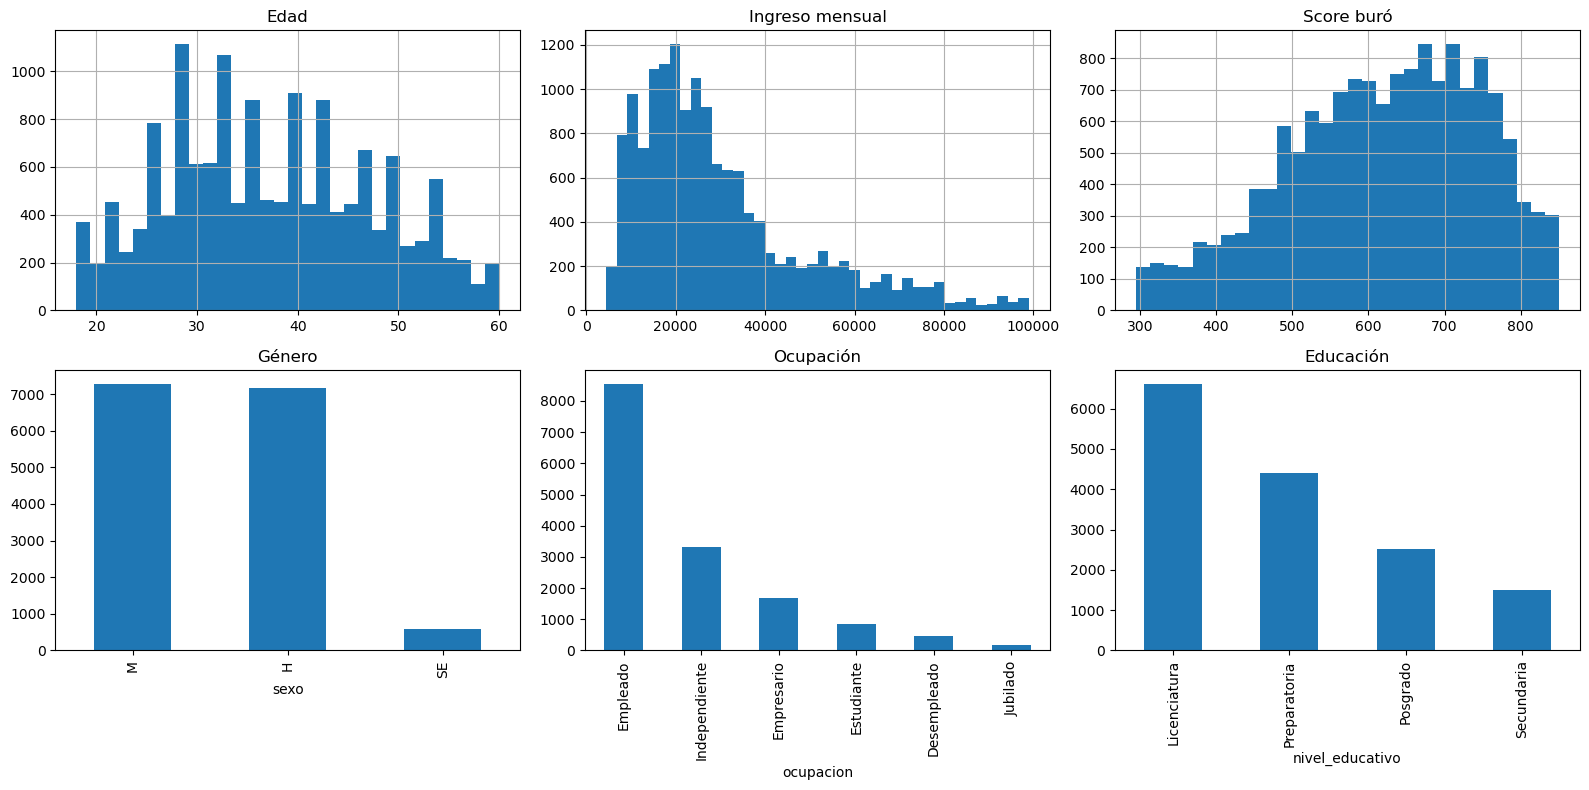

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

hey_clientes["edad"].hist(bins=30, ax=axes[0,0]); axes[0,0].set_title("Edad")
hey_clientes["ingreso_mensual_mxn"].hist(bins=40, ax=axes[0,1]); axes[0,1].set_title("Ingreso mensual")
hey_clientes["score_buro"].hist(bins=30, ax=axes[0,2]); axes[0,2].set_title("Score buró")
hey_clientes["sexo"].value_counts().plot(kind="bar", ax=axes[1,0]); axes[1,0].set_title("Género")
hey_clientes["ocupacion"].value_counts().plot(kind="bar", ax=axes[1,1]); axes[1,1].set_title("Ocupación")
hey_clientes["nivel_educativo"].value_counts().plot(kind="bar", ax=axes[1,2]); axes[1,2].set_title("Educación")

plt.tight_layout(); plt.show()

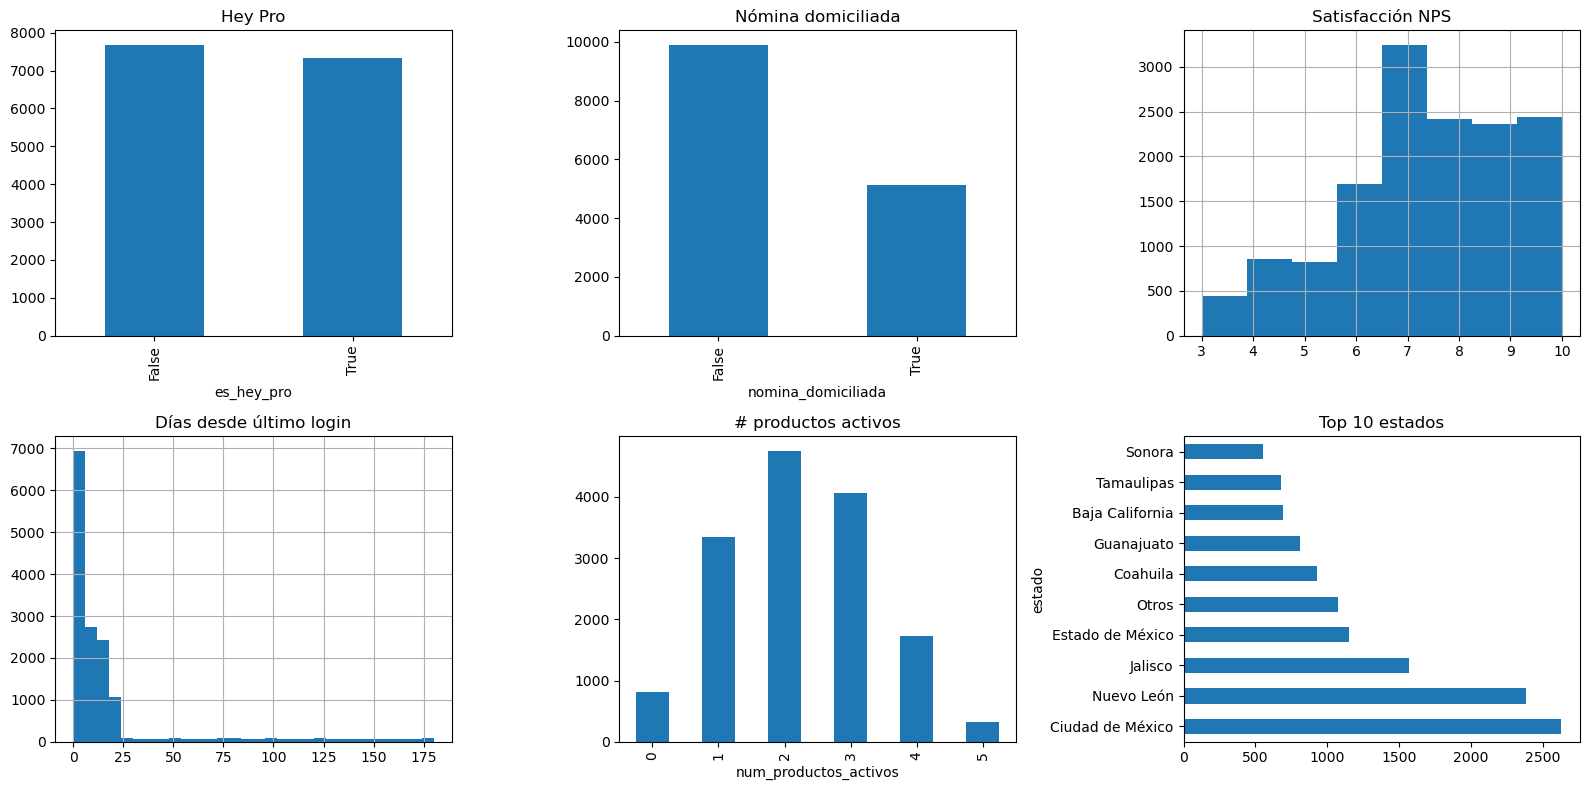

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

hey_clientes["es_hey_pro"].value_counts().plot(kind="bar", ax=axes[0,0]); axes[0,0].set_title("Hey Pro")
hey_clientes["nomina_domiciliada"].value_counts().plot(kind="bar", ax=axes[0,1]); axes[0,1].set_title("Nómina domiciliada")
hey_clientes["satisfaccion_1_10"].hist(bins=8, ax=axes[0,2]); axes[0,2].set_title("Satisfacción NPS")
hey_clientes["dias_desde_ultimo_login"].hist(bins=30, ax=axes[1,0]); axes[1,0].set_title("Días desde último login")
hey_clientes["num_productos_activos"].value_counts().sort_index().plot(kind="bar", ax=axes[1,1]); axes[1,1].set_title("# productos activos")
hey_clientes["estado"].value_counts().head(10).plot(kind="barh", ax=axes[1,2]); axes[1,2].set_title("Top 10 estados")

plt.tight_layout(); plt.show()

In [11]:
hey_clientes["estado"].unique()

<StringArray>
['Ciudad de México',          'Jalisco',        'Chihuahua',
       'Nuevo León',            'Otros',  'Baja California',
                nan,         'Coahuila',       'Guanajuato',
           'Puebla',        'Querétaro',       'Tamaulipas',
           'Oaxaca',         'Veracruz',          'Sinaloa',
 'Estado de México',           'Sonora',          'Yucatán']
Length: 18, dtype: str

## EDA productos

Tipos de producto:
tipo_producto
cuenta_debito                  15025
tarjeta_credito_hey             7565
inversion_hey                   4474
seguro_vida                     2480
credito_nomina                  2044
credito_personal                1549
cuenta_negocios                 1343
seguro_compras                  1270
tarjeta_credito_negocios        1111
tarjeta_credito_garantizada     1091
credito_auto                     957
Name: count, dtype: int64

Estatus:
estatus
activo               33548
cancelado             2917
suspendido            1426
revision_de_pagos     1018
Name: count, dtype: int64

Productos por usuario (estadística):
count    15025.000000
mean         2.589617
std          1.047195
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          5.000000
dtype: float64


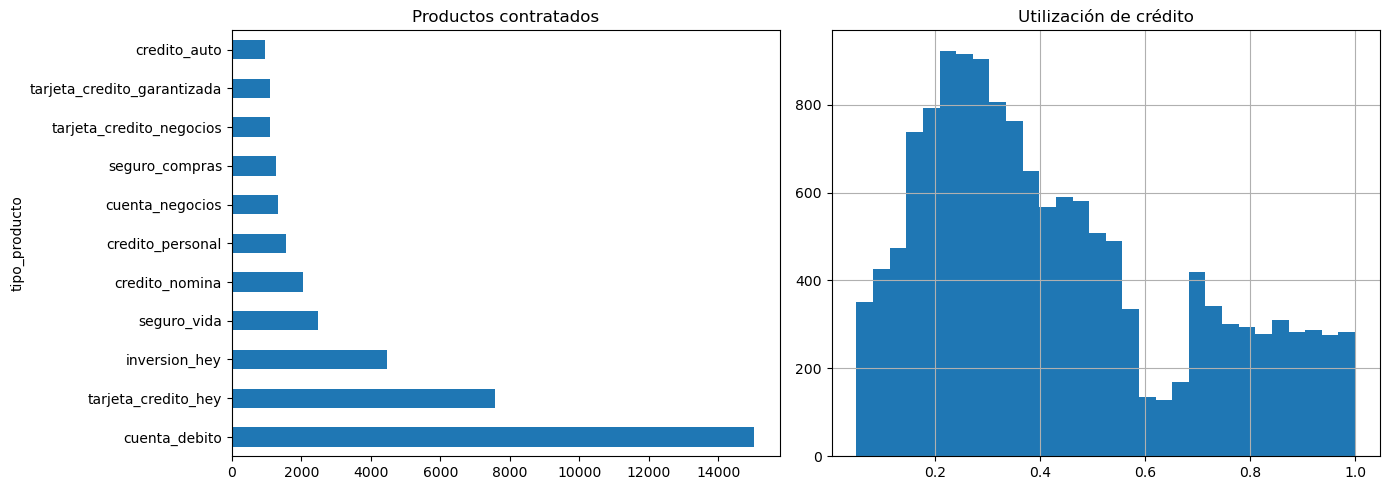

In [12]:
print("Tipos de producto:")
print(hey_productos["tipo_producto"].value_counts())
print("\nEstatus:")
print(hey_productos["estatus"].value_counts())
print("\nProductos por usuario (estadística):")
print(hey_productos.groupby("user_id").size().describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hey_productos["tipo_producto"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("Productos contratados")
hey_productos["utilizacion_pct"].dropna().hist(bins=30, ax=axes[1])
axes[1].set_title("Utilización de crédito")
plt.tight_layout(); plt.show()

## EDA transacciones

In [13]:
print(f"Total transacciones: {len(hey_transacciones):,}")
print(f"Rango fechas: {hey_transacciones.fecha_hora.min()} a {hey_transacciones.fecha_hora.max()}")
print(f"\nTransacciones por usuario:")
print(hey_transacciones.groupby("user_id").size().describe())
print(f"\nMonto:")
print(hey_transacciones["monto"].describe())

Total transacciones: 802,384
Rango fechas: 2025-01-01 08:00:09 a 2025-12-15 13:59:36

Transacciones por usuario:
count    15025.000000
mean        53.403261
std         23.003565
min          5.000000
25%         39.000000
50%         56.000000
75%         68.000000
max        101.000000
dtype: float64

Monto:
count    802384.000000
mean       6108.495959
std        9885.308664
min           5.010000
25%         540.000000
50%        1740.000000
75%        7030.937500
max       79511.300000
Name: monto, dtype: float64


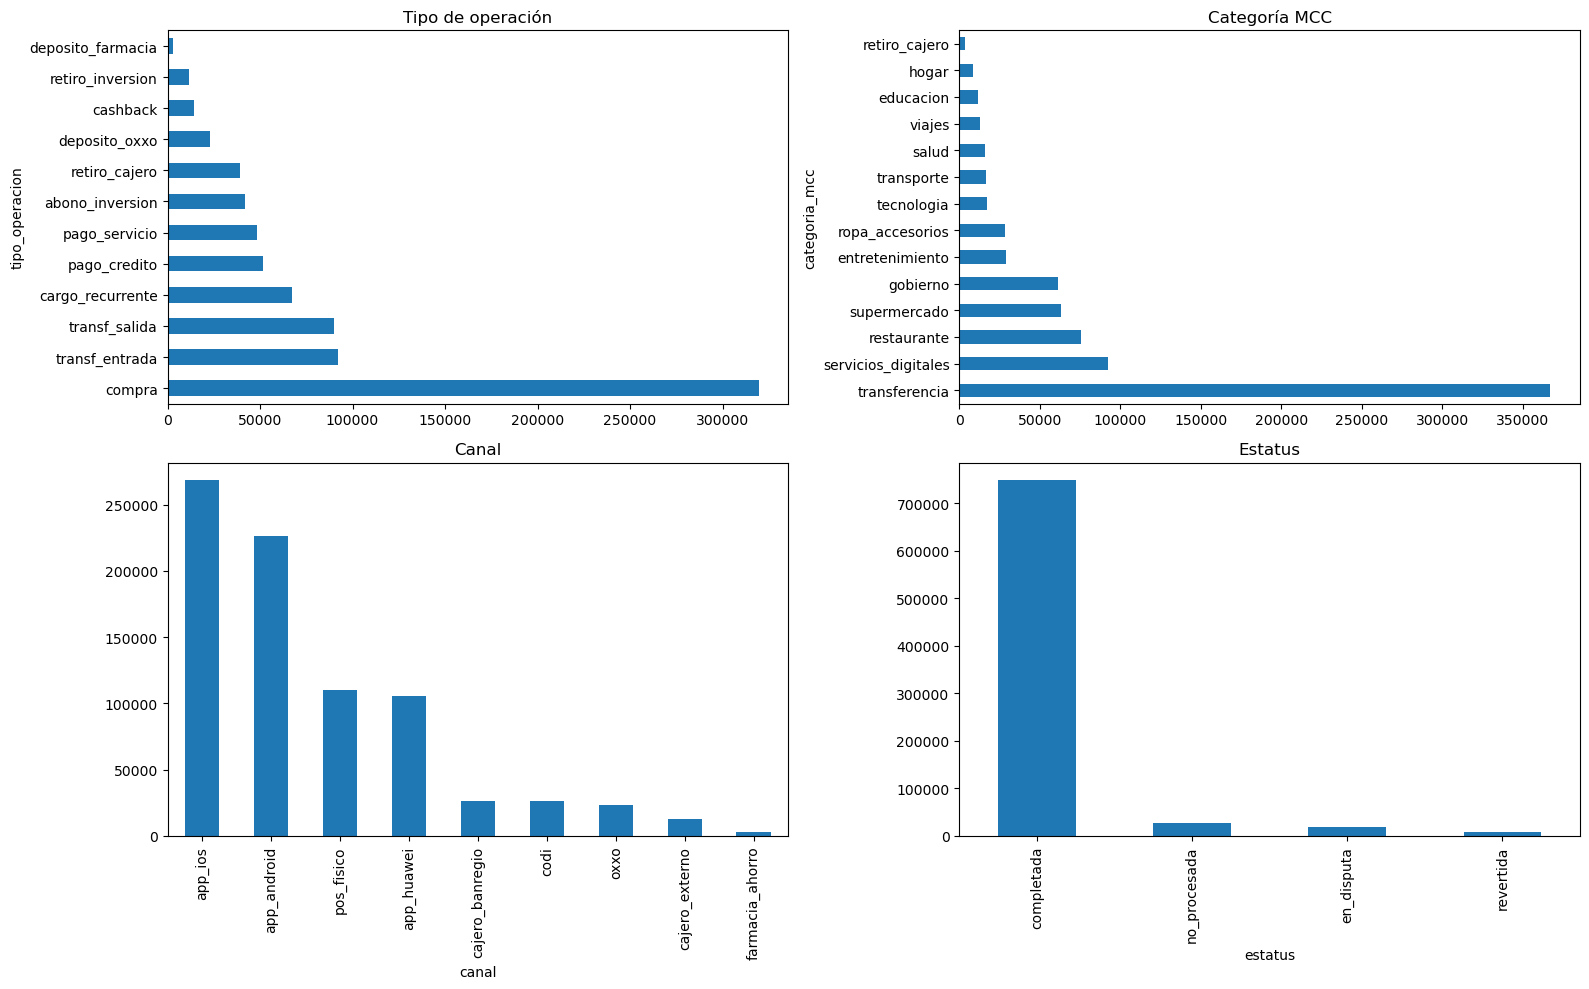

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

hey_transacciones["tipo_operacion"].value_counts().plot(kind="barh", ax=axes[0,0])
axes[0,0].set_title("Tipo de operación")

hey_transacciones["categoria_mcc"].value_counts().plot(kind="barh", ax=axes[0,1])
axes[0,1].set_title("Categoría MCC")

hey_transacciones["canal"].value_counts().plot(kind="bar", ax=axes[1,0])
axes[1,0].set_title("Canal")

hey_transacciones["estatus"].value_counts().plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Estatus")

plt.tight_layout(); plt.show()

% no procesadas: 3.32%

Motivos:
motivo_no_procesada
monto_excede_limite_diario    3366
datos_invalidos               3342
tarjeta_bloqueada             3342
saldo_insuficiente            3334
codigo_incorrecto             3326
cuenta_destino_invalida       3325
limite_excedido               3304
timeout_banco                 3270
Name: count, dtype: int64


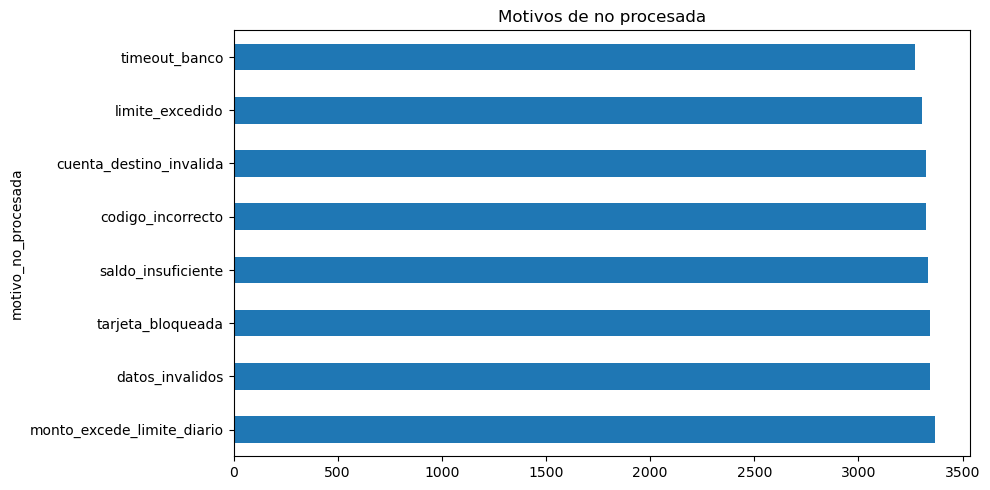

In [15]:
no_proc = hey_transacciones[hey_transacciones.estatus == "no_procesada"]
print(f"% no procesadas: {len(no_proc)/len(hey_transacciones):.2%}")
print(f"\nMotivos:")
print(no_proc["motivo_no_procesada"].value_counts())

no_proc["motivo_no_procesada"].value_counts().plot(
    kind="barh", figsize=(10, 5), title="Motivos de no procesada")
plt.tight_layout(); plt.show()

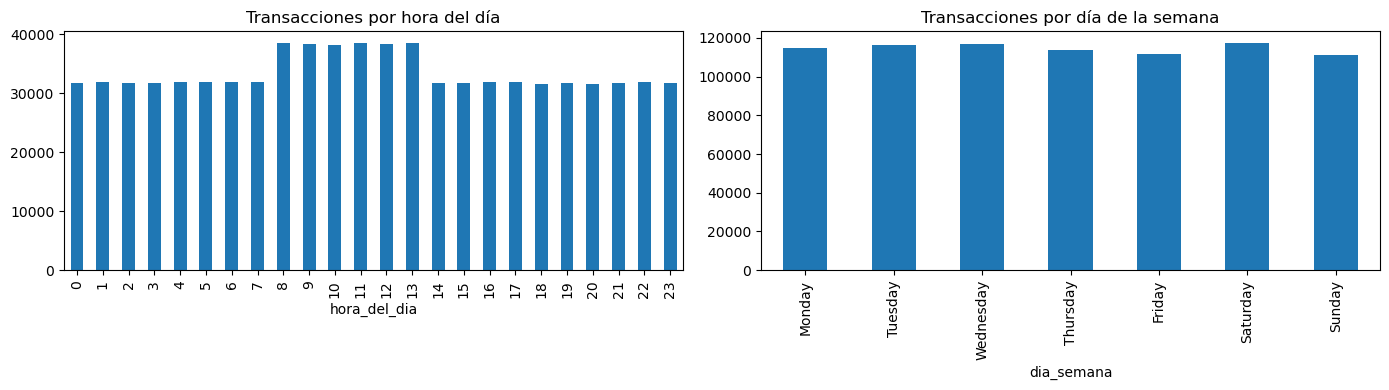

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hey_transacciones["hora_del_dia"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Transacciones por hora del día")

orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
hey_transacciones["dia_semana"].value_counts().reindex(orden_dias).plot(kind="bar", ax=axes[1])
axes[1].set_title("Transacciones por día de la semana")

plt.tight_layout(); plt.show()

## EDA Conversaciones

Interacciones: 49,999
Conversaciones únicas: 24,119
Usuarios únicos: 15,025

Canal:
channel_source
1    46936
2     3063
Name: count, dtype: int64

Turnos por conversación:
count    24119.000000
mean         2.073013
std          1.599693
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         21.000000
dtype: float64


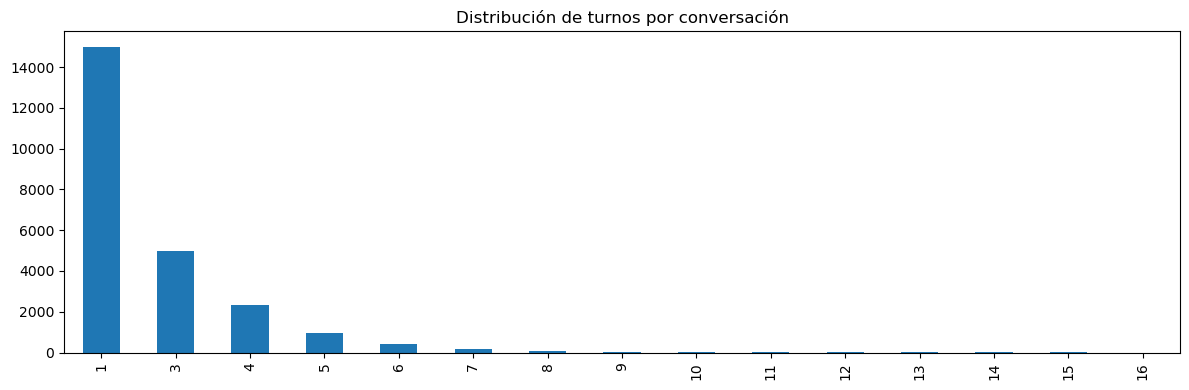

In [17]:
print(f"Interacciones: {len(df):,}")
print(f"Conversaciones únicas: {df.conv_id.nunique():,}")
print(f"Usuarios únicos: {df.user_id.nunique():,}")
print(f"\nCanal:")
print(df["channel_source"].value_counts())

turnos = df.groupby("conv_id").size()
print(f"\nTurnos por conversación:")
print(turnos.describe())

turnos.value_counts().sort_index().head(15).plot(
    kind="bar", figsize=(12,4), title="Distribución de turnos por conversación")
plt.tight_layout(); plt.show()

# Validación de relaciones entre tablas

In [18]:
users_clientes = set(hey_clientes.user_id)
users_conv = set(df.user_id)
users_tx = set(hey_transacciones.user_id)

print("Clientes:", len(users_clientes))
print("Con conversaciones:", len(users_clientes & users_conv))
print("Con transacciones:", len(users_clientes & users_tx))
print("Con los 3:", len(users_clientes & users_conv & users_tx))

Clientes: 15025
Con conversaciones: 15025
Con transacciones: 15025
Con los 3: 15025


Todos los usuarios cuentan con conversaciones y transacciones (y por ende tienen al menos un producto)

In [19]:
sample_convs = df.conv_id.drop_duplicates().sample(3, random_state=42)
for cid in sample_convs:
    print(f"\n{'='*60}\nCONV {cid}")
    turnos = df[df.conv_id == cid].sort_values("date")
    for _, t in turnos.iterrows():
        print(f"\n[USUARIO]: {t['input'][:200]}")
        print(f"[BOT]:     {t['output'][:200]}")


CONV 4843737D-705A-4A23-917B-0CBAE46B4619

[USUARIO]: Hola
[BOT]:     ¡Hola! ¿Cómo estás? Estoy aquí para ayudarte con cualquier pregunta que tengas sobre nuestros productos y servicios en Hey Banco, o sobre temas de finanzas personales. ¿En qué puedo asistirte hoy?

[USUARIO]: Mi tarjeta venció
[BOT]:     Lamento escuchar eso. No te preocupes, cuando tu tarjeta de débito vence, se actualiza automáticamente y te dan una nueva. Si necesitas más información o ayuda con otro tema, ¡no dudes en decírmelo! ¿

[USUARIO]: Donde me la dan?
[BOT]:     Claro! Puedes recoger tu nueva tarjeta física en una Fan Shop en Monterrey, Ciudad de México o Guadalajara. Solo asegúrate de llevar tu identificación oficial. Ten en cuenta que estas tarjetas son gen

[USUARIO]: Gracias
[BOT]:     ¡De nada! Si tienes más preguntas o necesitas ayuda con algo más, no dudes en decírmelo. Estoy aquí para ayudarte. ¿Hay algo más en lo que pueda asistirte hoy?

CONV 54e32fbe-d84a-4270-8f15-61f88cb048cc

[USUARIO]: Qui

In [20]:
print("="*60)
print("RESUMEN EDA")
print("="*60)
print(f"\nUniverso:")
print(f"  - Clientes:        {len(hey_clientes):,}")
print(f"  - Productos:       {len(hey_productos):,}")
print(f"  - Transacciones:   {len(hey_transacciones):,}")
print(f"  - Conversaciones:  {len(df):,} interacciones / {df.conv_id.nunique():,} convs")
print(f"\nCobertura para análisis 360°:")
print(f"  - Usuarios con las 3 fuentes: {len(u_clientes & u_tx & u_conv):,}")
print(f"\nSeñales clave:")
print(f"  - % Hey Pro:                  {hey_clientes.es_hey_pro.mean():.1%}")
print(f"  - % nómina domiciliada:       {hey_clientes.nomina_domiciliada.mean():.1%}")
print(f"  - % patrón uso atípico:       {hey_clientes.patron_uso_atipico.mean():.1%}")
print(f"  - % tx no procesadas:         {(hey_transacciones.estatus=='no_procesada').mean():.2%}")
print(f"  - Satisfacción promedio:      {hey_clientes.satisfaccion_1_10.mean():.2f}")

RESUMEN EDA

Universo:
  - Clientes:        15,025
  - Productos:       38,909
  - Transacciones:   802,384
  - Conversaciones:  49,999 interacciones / 24,119 convs

Cobertura para análisis 360°:
  - Usuarios con las 3 fuentes: 15,025

Señales clave:
  - % Hey Pro:                  48.9%
  - % nómina domiciliada:       34.1%
  - % patrón uso atípico:       5.1%
  - % tx no procesadas:         3.32%
  - Satisfacción promedio:      7.48


In [21]:
hey_clientes.to_csv("../data/hey_clientes_clean.csv", index=False)
hey_productos.to_csv("../data/hey_productos_clean.csv", index=False)
hey_transacciones.to_csv("../data/hey_transacciones_clean.csv", index=False)